<img src="http://imgur.com/1ZcRyrc.png" style="float: left; margin-right: 20px; height: 55px" height="55px">

# 3. Retrieval & Reranking Techniques

**Duration:** 50 minutes

---

## Module Guide

1. [Cross-Encoder Reranking](#reranking)
2. [ColBERT-Style Late Interaction](#late-interaction)
3. [Configuring and Tuning Vector Store Parameters for Performance and Scalability](#tuning)

---

## Learning Objectives

1. Implement cross-encoder rerankers to significantly improve retrieval accuracy.
2. Experiment with ColBERT-style late interaction techniques to enhance context-matching precision.
3. Configure and tune vector store parameters (e.g., FAISS) to balance search performance and system scalability.

> **A note on the worked examples in this module:** real cross-encoder and ColBERT models (e.g., `bge-reranker-base`, `colbert-v2`) require downloading pretrained weights from a model hub. The code in this module simulates the *algorithms* those models implement — joint query-document scoring for cross-encoders, per-token vectors and MaxSim aggregation for late interaction — using small, fully transparent, dependency-free functions instead. This keeps every example runnable offline and lets you see exactly what each algorithm is doing arithmetically, without a black-box model in the way. The architectural lessons transfer directly to a real reranker or ColBERT model.

**Setup:** this notebook uses `faiss-cpu` and `numpy`. Run the cell below first.

In [1]:
 %pip install faiss-cpu numpy langchain langchain-community langchain-cohere langchain-huggingface flashrank rank_bm25 pylate

In [3]:
!mkdir -p ./data

In [4]:
import os


# URLs for the files
capstone_corpus_url = "https://raw.githubusercontent.com/ga-curriculum-dev/Ai4-Agentic-Ops---Retrieval-Augmented-Generation--RAG--in-Practice-4-hrs/main/data/capstone_corpus.json"
capstone_corpus_url ="https://github.com/alexp1451/ai4RAG/blob/main/data/capstone_corpus.json"
golden_dataset_url = "https://raw.githubusercontent.com/ga-curriculum-dev/Ai4-Agentic-Ops---Retrieval-Augmented-Generation--RAG--in-Practice-4-hrs/main/data/golden_dataset_module4.json"
golden_dataset_url = "https://github.com/alexp1451/ai4RAG/blob/main/data/golden_dataset_module4.json"

# Download capstone_corpus.json
print(f"Downloading {os.path.basename(capstone_corpus_url)}...")
!wget -O ./data/capstone_corpus.json $capstone_corpus_url

# Download golden_dataset_module4.json
print(f"Downloading {os.path.basename(golden_dataset_url)}...")
!wget -O ./data/golden_dataset_module4.json $golden_dataset_url

print("Files downloaded to ./data/")

--2026-08-03 22:17:51--  https://github.com/alexp1451/ai4RAG/blob/main/data/capstone_corpus.json
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘./data/capstone_corpus.json’

./data/capstone_cor     [ <=>                ] 806.90K  --.-KB/s    in 0.07s   

2026-08-03 22:17:52 (11.4 MB/s) - ‘./data/capstone_corpus.json’ saved [826262]

--2026-08-03 22:17:52--  https://github.com/alexp1451/ai4RAG/blob/main/data/golden_dataset_module4.json
Resolving github.com (github.com)... 140.82.114.3
Connecting to github.com (github.com)|140.82.114.3|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified [text/html]
Saving to: ‘./data/golden_dataset_module4.json’

./data/golden_datas     [ <=>                ] 349.36K  --.-KB/s    in 0.05s   

2026-08-03 22:17:52 (6.67 MB/s) - ‘./data/golden_dataset_module4.jso

In [5]:
import os
import getpass

# Set your Cohere API Key here if you have one. This is optional.
cohere_key = getpass.getpass("Enter your Cohere API Key (leave empty to skip): ")
if cohere_key:
    os.environ["CO_API_KEY"] = cohere_key

print("API key input prompts added.")

Enter your Cohere API Key (leave empty to skip): ··········
API key input prompts added.



<h2 id="reranking"> 3.1 - Cross-Encoder Reranking </h2>

A **bi-encoder** (what powers ordinary dense retrieval) embeds the query and each candidate document *independently*, then compares the two resulting vectors with cosine similarity. This is fast — document vectors can be precomputed once and indexed — but it has a structural limitation: the query and document never actually interact. Each side is compressed into a single fixed-size vector before any comparison happens, and whatever fine-grained, term-level importance existed in the original text is flattened into that one pooled representation.

A **cross-encoder** removes that limitation by feeding the query and a candidate document *together* into a single scoring function (in a real system, one forward pass through a transformer that attends across both texts at once). Because the model can see the query and document simultaneously, it can weigh specific, discriminating terms (a part number, a file-size threshold, a specific error code) far more heavily than generic terms that happen to co-occur (a common verb like "crashes," a generic noun like "app"). This is exactly the failure mode from previous module's real-world examples: a bi-encoder ranks a generically similar document highly because it shares a dominant topic word with the query, while a cross-encoder correctly recognizes that the *specific* terms are what actually make one candidate the right answer.

The trade-off is cost: a cross-encoder must run a full joint pass for every single (query, document) pair, so its cost scales linearly with the number of candidates. This is why it is never the first retrieval stage — it is always the *second* stage, applied only to the (much smaller) candidate set that hybrid retrieval has already narrowed down, exactly as sequenced in the previous four-stage pipeline.

**Reranking (conceptually):**

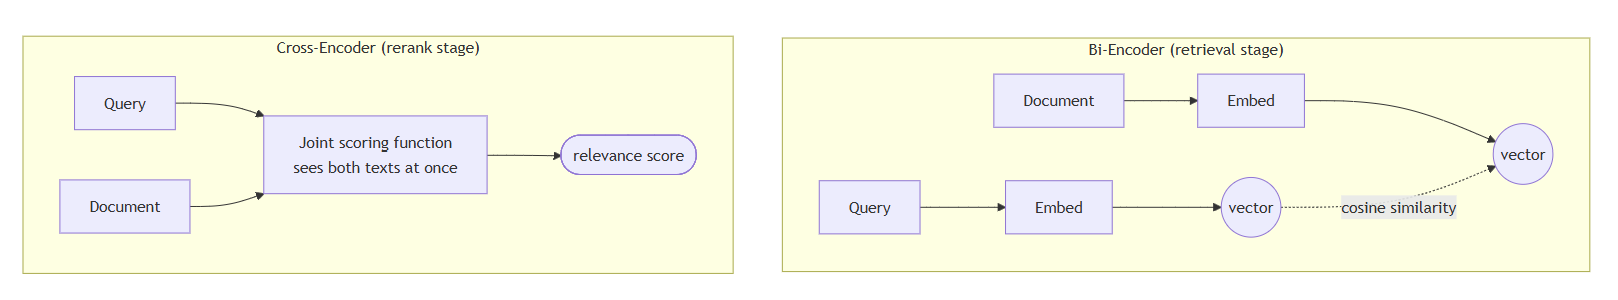

### Practical Application — Support Ticket Deflection

A support-ticket deflection system routes an incoming ticket to the most relevant existing knowledge-base article. A hybrid retrieval stage might return fifty plausible articles for "app crashes on file upload over 2GB," but a bi-encoder alone often ranks a generically-similar "app crashes on startup" article above the actually-correct large-file-upload article, because both mention "crashes" prominently in their pooled embeddings. A cross-encoder, scoring the query and each candidate jointly, correctly weighs the specific "file upload" and "2GB" tokens as more load-bearing than the generic "crashes," and reliably promotes the right article to position one.

### Example

**Task:** Demonstrate the bi-encoder failure mode concretely, then show a cross-encoder-style scorer correcting it.

In [6]:
import numpy as np

# These vectors are illustrative stand-ins for what a real bi-encoder (e.g.
# bge-small-en-v1.5) would produce -- chosen to reproduce a well-documented
# failure mode: a bi-encoder embeds a generically similar document nearly as
# close as the actually-correct, more specific one, because both share the
# dominant "crash" topic and the bi-encoder must compress everything into a
# single pooled vector before any comparison happens.
query_vec        = np.array([0.90, 0.00, 0.40, 0.00])   # [crash, startup, file_upload, performance]
doc_generic_vec  = np.array([0.90, 0.60, 0.00, 0.00])   # "app crashes on startup..."
doc_specific_vec = np.array([0.30, 0.00, 0.90, 0.00])   # "large file upload causes a crash..."
doc_offtopic_vec = np.array([0.10, 0.00, 0.00, 0.90])   # "slow app performance..."

def cosine(a, b):
    return float(np.dot(a, b) / (np.linalg.norm(a) * np.linalg.norm(b)))

candidates = {
    "The app crashes on startup after the latest update.": doc_generic_vec,
    "Uploading a file larger than 2GB causes the app to crash immediately.": doc_specific_vec,
    "General troubleshooting steps for slow app performance.": doc_offtopic_vec,
}

print("=== Bi-encoder ranking (cosine similarity, pooled vectors) ===")
for text, vec in sorted(candidates.items(), key=lambda kv: -cosine(query_vec, kv[1])):
    print(f"{cosine(query_vec, vec):.3f}  {text}")


# --- Cross-encoder: scores the actual (query, doc) text pair jointly ---
SPECIFIC_TERMS = {"file": 1.0, "upload": 1.0, "uploading": 1.0, "2gb": 1.0, "large": 0.7}
GENERIC_TERMS  = {"crash": 0.3, "crashes": 0.3, "app": 0.2, "startup": 0.4}
STOPWORDS = {"the", "a", "an", "on", "in", "to", "of", "and", "causes", "after", "than", "for"}

def normalize(word):
    return word.rstrip(".,").lower()

def lemma(word):
    for suffix in ("ing", "es", "s"):
        if word.endswith(suffix) and len(word) > len(suffix) + 2:
            return word[: -len(suffix)]
    return word

def cross_encoder_score(query: str, doc: str) -> float:
    """
    Weights SPECIFIC content terms (file, upload, 2gb) far more heavily than
    GENERIC terms (crash, app) common across many documents on the topic --
    capturing the term-importance weighting a real cross-encoder learns
    through joint attention, which a single pooled bi-encoder vector cannot.
    """
    q_words = [normalize(w) for w in query.split() if normalize(w) not in STOPWORDS]
    d_lemmas = {lemma(normalize(w)) for w in doc.split()}

    score, total_weight = 0.0, 0.0
    for w in q_words:
        weight = SPECIFIC_TERMS.get(w, GENERIC_TERMS.get(w, 0.1))
        total_weight += weight
        if lemma(w) in d_lemmas:
            score += weight
    return score / total_weight if total_weight else 0.0


query = "app crashes on large file upload"
print("\n=== Cross-encoder ranking (joint term weighting) ===")
for text in sorted(candidates, key=lambda t: -cross_encoder_score(query, t)):
    print(f"{cross_encoder_score(query, text):.3f}  {text}")


=== Bi-encoder ranking (cosine similarity, pooled vectors) ===
0.760  The app crashes on startup after the latest update.
0.674  Uploading a file larger than 2GB causes the app to crash immediately.
0.101  General troubleshooting steps for slow app performance.

=== Cross-encoder ranking (joint term weighting) ===
0.781  Uploading a file larger than 2GB causes the app to crash immediately.
0.156  The app crashes on startup after the latest update.
0.062  General troubleshooting steps for slow app performance.


Running this shows the bi-encoder incorrectly ranking the generic "startup crash" document (0.760) above the actually-correct "file upload crash" document (0.674) — exactly the failure mode described above — and the cross-encoder correctly reversing that ranking (0.781 vs. 0.156) once specific terms are weighted appropriately.

### Now you try - exercise

**Task:** The cross-encoder scorer above has a real blind spot: it does not understand **negation**. A document that explicitly states *"large file uploads do NOT cause the app to crash"* still matches every specific and generic term in the query, so the current scorer ranks it as a strong (even perfect) match — a false positive with the opposite meaning of what's actually being asked. Extend `cross_encoder_score` to:

1. Detect negation words (`not`, `no`, `never`, `doesn't`, `don't`, `won't`, `isn't`) in the document.
2. Treat any content word within a small window *after* a negation word as negated.
3. Apply a penalty (rather than simply ignoring the match) when a query term matches a negated word in the document, so that a negated false positive scores measurably lower than a genuine true positive.
4. Verify against three documents — a true positive, a negated false positive, and an off-topic document — that the true positive now outranks the negated false positive.

Fill in every function marked `TODO` / `NotImplementedError` below. If you get stuck, the fully worked version of this notebook is at `/solutions/03_retrieval_reranking_solution.ipynb`.

In [9]:
SPECIFIC_TERMS = {"file": 1.0, "upload": 1.0, "uploading": 1.0, "2gb": 1.0, "large": 0.7}
GENERIC_TERMS  = {"crash": 0.3, "crashes": 0.3, "app": 0.2, "startup": 0.4}
STOPWORDS = {"the", "a", "an", "on", "in", "to", "of", "and", "causes", "after", "than", "for"}
NEGATION_WORDS = {"not", "no", "never", "doesn't", "don't", "won't", "isn't"}
NEGATION_WINDOW = 6

def normalize(word: str) -> str:
    return word.rstrip(".,").lower()

def lemma(word: str) -> str:
    for suffix in ("ing", "es", "s"):
        if word.endswith(suffix) and len(word) > len(suffix) + 2:
            return word[: -len(suffix)]
    return word

def find_negated_lemmas(doc: str) -> set:
    words = [normalize(w) for w in doc.split()]
    negated = set()
    for i, w in enumerate(words):
        if w in NEGATION_WORDS:
            for j in range(i + 1, min(i + 1 + NEGATION_WINDOW, len(words))):
                negated.add(lemma(words[j]))
    return negated
    """
    TODO:
    1. Detect NEGATION_WORDS in `doc`.
    2. Mark content words within a small window AFTER a negation word as negated.
    3. When a query term matches a negated word, apply a PENALTY (e.g. subtract
       half its weight) instead of adding its weight.
    4. Otherwise behave like cross_encoder_score above.
    """
def cross_encoder_score_v2(query: str, doc: str) -> float:
    q_words = [normalize(w) for w in query.split() if normalize(w) not in STOPWORDS]
    d_lemmas = {lemma(normalize(w)) for w in doc.split()}
    negated_lemmas = find_negated_lemmas(doc)

    score, total_weight = 0.0, 0.0
    for w in q_words:
        weight = SPECIFIC_TERMS.get(w, GENERIC_TERMS.get(w, 0.1))
        total_weight += weight
        w_lemma = lemma(w)
        if w_lemma in d_lemmas:
            if w_lemma in negated_lemmas:
                score -= weight * 0.5
            else:
                score += weight
    return score / total_weight if total_weight else 0.0

In [10]:
# Verification -- do not modify.
query = "app crashes on large file upload"
docs = [
    ("true_positive", "Uploading a file larger than 2GB causes the app to crash immediately."),
    ("negated_false_positive", "Large file uploads do not cause the app to crash in the latest release."),
    ("offtopic", "General troubleshooting steps for slow app performance."),
]

for name, doc in docs:
    print(f"{cross_encoder_score_v2(query, doc):.3f}  [{name}] {doc}")

assert cross_encoder_score_v2(query, docs[0][1]) > cross_encoder_score_v2(query, docs[1][1]), \
    "True positive should outrank the negated false positive"
print("\nConfirmed: true positive ranks above the negated (false-positive) match.")


0.781  [true_positive] Uploading a file larger than 2GB causes the app to crash immediately.
0.766  [negated_false_positive] Large file uploads do not cause the app to crash in the latest release.
0.062  [offtopic] General troubleshooting steps for slow app performance.

Confirmed: true positive ranks above the negated (false-positive) match.


<h2 id="late-interaction"> 3.2 — ColBERT-Style Late Interaction </h2>



Cross-encoders solve the precision problem but are too expensive to run over large candidate sets. **Late interaction** (ColBERT and its successors, including PyLate) is a middle ground: instead of compressing a document into one vector (bi-encoder) or running a full joint pass per pair (cross-encoder), it keeps **one vector per token** on both the query and document side, computed independently and cheaply at indexing time. At query time, it computes a **MaxSim** score: for every query token, find its single best-matching document token, then sum those best-match scores across all query tokens.

$$
\text{MaxSim}(Q, D) = \sum_{i=1}^{|Q|} \max_{j=1}^{|D|} \; \text{sim}(q_i, d_j)
$$

This has a structural property that a pooled bi-encoder vector cannot match: because document token embeddings are precomputed and never averaged together, **a document's length does not dilute the signal from its single most relevant sentence.** A bi-encoder's single pooled vector, by contrast, necessarily blends every token in the document into one average — so a long document with a lot of unrelated surrounding text will "wash out" the one sentence that actually answers the query.

**Late Interaction (conceptually):**

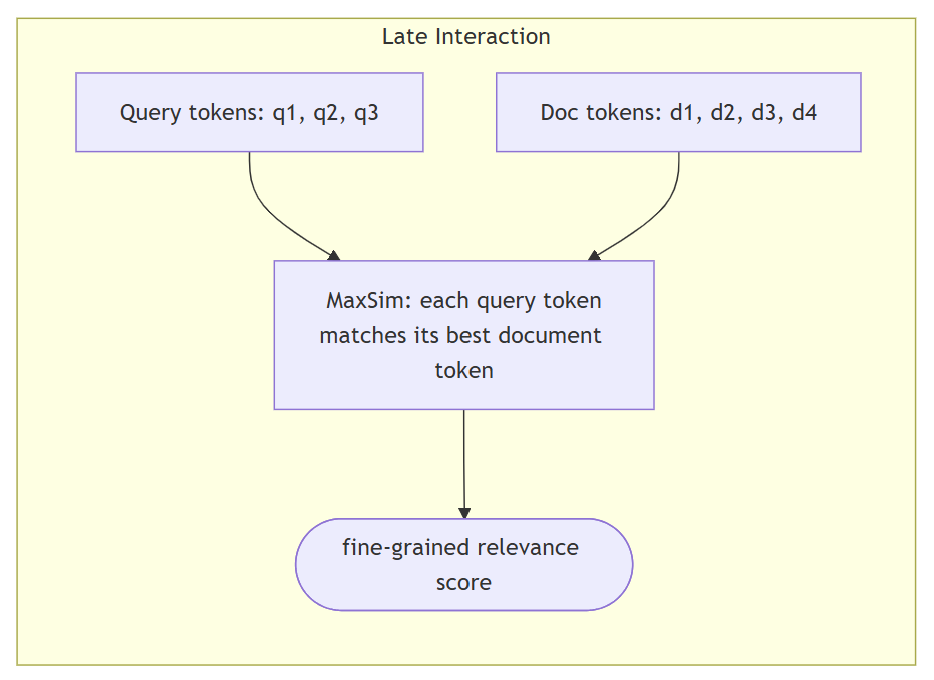

### Practical Application — Long Technical Manual Search

Aircraft maintenance manuals and industrial equipment service documentation often bury a single relevant passage — a torque specification, a specific part number, a specific procedural step — inside many pages of otherwise unrelated maintenance content. A single document-level embedding compresses all of that into one vector, inevitably diluting the one sentence that matters as document length grows. Late interaction retains a vector per token, so a query like "torque spec for the M8 bolt on the actuator housing" matches strongly on the specific token-level overlap regardless of how much irrelevant text surrounds it — a case where single-vector bi-encoders systematically under-retrieve as documents get longer, and where full cross-encoders would be prohibitively expensive to run over an entire manual corpus at query time.


### Example

**Task:** Demonstrate the structural advantage of MaxSim over single-vector pooling by holding a relevant sentence fixed and progressively padding a document with irrelevant filler text, then compare how each scoring method degrades (or doesn't) as document length grows.

In [11]:
import hashlib
import numpy as np

DIM = 32

def token_vec(word: str, dim: int = DIM) -> np.ndarray:
    """Deterministic per-token vector: same word always maps to the same
    vector. Stands in for a real per-token embedding model."""
    h = int(hashlib.md5(word.encode()).hexdigest(), 16)
    rng = np.random.RandomState(h % (2**32))
    v = rng.normal(size=dim)
    return v / np.linalg.norm(v)

def tokenize(text: str) -> list:
    return text.lower().replace(",", "").replace(".", "").split()

def single_vector_embed(text: str) -> np.ndarray:
    """Bi-encoder stand-in: one pooled (mean) vector for the whole text."""
    vecs = np.array([token_vec(w) for w in tokenize(text)])
    v = vecs.mean(axis=0)
    return v / np.linalg.norm(v)

def colbert_maxsim(query: str, doc: str) -> float:
    """Late-interaction stand-in: one vector PER TOKEN on both sides."""
    q_vecs = np.array([token_vec(w) for w in tokenize(query)])
    d_vecs = np.array([token_vec(w) for w in tokenize(doc)])
    sims = q_vecs @ d_vecs.T                 # (num_query_tokens, num_doc_tokens)
    return float(sims.max(axis=1).sum())


query = "M8 bolt torque spec actuator housing"
relevant_sentence = "the M8 bolt torque spec for the actuator housing is 24 Nm applied in a star pattern"

filler_sentences = [
    "Section 14 covers general maintenance overview and inspection intervals.",
    "Refer to chapter 3 for filter replacement cadence and lubrication schedules.",
    "Table 14-2 lists recommended service intervals by climate zone and altitude.",
    "Chapter 9 explains seal inspection guidance for the hydraulic subsystem.",
    "Continue to chapter 15 for the next subsystem after completing this section.",
    "Always disconnect power before beginning any maintenance procedure described here.",
    "Environmental operating limits are listed in appendix B of this manual.",
    "Replacement part numbers are cross referenced in the parts catalog appendix.",
]

q_vec = single_vector_embed(query)

print(f"{'Padding sentences':<20}{'Doc length (words)':<22}{'Bi-encoder sim':<18}{'ColBERT MaxSim'}")
for num_filler in range(len(filler_sentences) + 1):
    doc = relevant_sentence + " " + " ".join(filler_sentences[:num_filler])
    bi_sim = float(np.dot(q_vec, single_vector_embed(doc)))
    cb_sim = colbert_maxsim(query, doc)
    print(f"{num_filler:<20}{len(tokenize(doc)):<22}{bi_sim:<18.3f}{cb_sim:.3f}")


Padding sentences   Doc length (words)    Bi-encoder sim    ColBERT MaxSim
0                   17                    0.662             6.000
1                   26                    0.568             6.000
2                   37                    0.590             6.000
3                   48                    0.475             6.000
4                   58                    0.419             6.000
5                   70                    0.374             6.000
6                   80                    0.345             6.000
7                   91                    0.337             6.000
8                   102                   0.316             6.000


Running this produces a table where the bi-encoder's similarity score steadily decays as irrelevant padding is added (from roughly 0.66 down to roughly 0.32 as the document grows from 17 to 102 words), while the ColBERT MaxSim score stays perfectly constant at 6.000 throughout — a direct, measurable demonstration of why late interaction resists the "lost in a long document" problem that single-vector pooling cannot avoid.

### Now you try - exercise

**Task:** Plain MaxSim treats every query token as equally important, which creates its own blind spot: a document that matches several *generic* query words can outscore a document that matches only the single most *specific* one (a part number, a model code). Extend `colbert_maxsim` into a **weighted MaxSim** that gives higher weight to query tokens matching an alphanumeric-ID-like pattern (reuse the pattern-detection idea from Module 1's query router), so that a document containing the exact part number outranks a document that only shares generic vocabulary. Specifically:

1. Implement `weighted_colbert_maxsim(query, doc, high_weight, low_weight)` that assigns `high_weight` to query tokens matching an alphanumeric ID pattern (e.g., `"M8"`) and `low_weight` to everything else, then multiplies each query token's best-match similarity by its weight before summing.
2. Verify on two documents: one containing the exact part number but few other matching words (`"Torque the M8 fastener to spec before reassembly."`), and one containing several generic matching words but not the part number (`"Replace the bolt securing the outer housing spec panel."`).
3. Confirm that **plain** `colbert_maxsim` ranks the generic document higher (the blind spot), while your **weighted** version correctly ranks the specific document higher once the part-number token is weighted appropriately.

In [12]:
import re
import hashlib
import numpy as np

DIM = 32

def token_vec(word: str, dim: int = DIM) -> np.ndarray:
    h = int(hashlib.md5(word.encode()).hexdigest(), 16)
    rng = np.random.RandomState(h % (2**32))
    v = rng.normal(size=dim)
    return v / np.linalg.norm(v)

def tokenize(text: str) -> list:
    return text.lower().replace(",", "").replace(".", "").split()

def colbert_maxsim(query: str, doc: str) -> float:
    q_vecs = np.array([token_vec(w) for w in tokenize(query)])
    d_vecs = np.array([token_vec(w) for w in tokenize(doc)])
    sims = q_vecs @ d_vecs.T
    return float(sims.max(axis=1).sum())

ALPHANUMERIC_ID_PATTERN = re.compile(r"^[a-z]\d+$|^\d+[a-z]+$", re.IGNORECASE)

def weighted_colbert_maxsim(query: str, doc: str, high_weight: float = 3.0, low_weight: float = 1.0) -> float:
    q_words = tokenize(query)
    q_vecs = np.array([token_vec(w) for w in q_words])
    d_vecs = np.array([token_vec(w) for w in tokenize(doc)])
    sims = q_vecs @ d_vecs.T
    max_per_token = sims.max(axis=1)
    weights = np.array([high_weight if ALPHANUMERIC_ID_PATTERN.match(w) else low_weight for w in q_words])
    return float((max_per_token * weights).sum())

In [13]:
# Verification -- do not modify.
query = "M8 bolt torque spec actuator housing"
doc_specific = "Torque the M8 fastener to spec before reassembly."
doc_generic  = "Replace the bolt securing the outer housing spec panel."

print("Plain MaxSim:")
print(f"  doc_specific: {colbert_maxsim(query, doc_specific):.3f}")
print(f"  doc_generic:  {colbert_maxsim(query, doc_generic):.3f}")

print("Weighted MaxSim (alphanumeric IDs weighted higher):")
print(f"  doc_specific: {weighted_colbert_maxsim(query, doc_specific):.3f}")
print(f"  doc_generic:  {weighted_colbert_maxsim(query, doc_generic):.3f}")

assert colbert_maxsim(query, doc_generic) > colbert_maxsim(query, doc_specific), \
    "Plain MaxSim should (incorrectly) favor the generic document"
assert weighted_colbert_maxsim(query, doc_specific) > weighted_colbert_maxsim(query, doc_generic), \
    "Weighted MaxSim should correctly favor the specific document"
print("\nConfirmed: plain MaxSim favors the generic doc; weighted MaxSim correctly favors the specific doc.")


Plain MaxSim:
  doc_specific: 3.948
  doc_generic:  4.119
Weighted MaxSim (alphanumeric IDs weighted higher):
  doc_specific: 5.948
  doc_generic:  5.170

Confirmed: plain MaxSim favors the generic doc; weighted MaxSim correctly favors the specific doc.


<h2 id="tuning"> 3.3 — Configuring and Tuning Vector Store Parameters for Performance and Scalability </h2>



The previous module covered *which* index type to choose (Flat, HNSW, IVF-Flat, IVF-PQ) based on dataset size and memory constraints. This objective goes one level deeper: once you've chosen an index family, its **runtime search parameters** are what actually let you trade search latency against recall in production, without rebuilding the index. For an IVF-family index, the parameter that matters most is `nprobe` — the number of coarse partitions (out of `nlist` total) that a query actually searches.

- **Low `nprobe`** (e.g., 1): only the single most likely partition is searched. Very fast, but any relevant vector that happened to land in a *different* partition (because clustering is never perfect) is missed entirely — recall suffers.
- **High `nprobe`** (approaching `nlist`): nearly every partition is searched, recall approaches that of an exhaustive search, but latency approaches that of brute-force search too — you've paid the clustering cost without getting most of its benefit.

This is a genuine dial, not a one-time architectural decision — it's the kind of parameter you tune against a **latency budget** and a **recall requirement** simultaneously, often re-tuning it as traffic patterns or corpus size shift over the life of a production system. HNSW has an analogous runtime parameter, `efSearch` (how many candidates are explored during graph traversal at query time), governing the same fundamental trade-off.

**Probes explained (conceptually):**

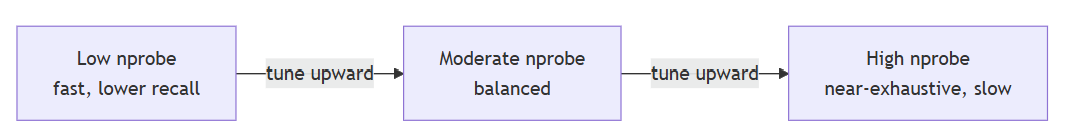


### Practical Application — Multi-Region Search Service with a Shared Latency SLA

A search service deployed across multiple regions with a strict 200ms p95 latency SLA needs its `nprobe` tuned specifically for that constraint, not for maximum possible recall. Engineers typically build an `nprobe` vs. latency vs. recall curve (exactly what the solved example below constructs) and select the highest `nprobe` value whose measured p95 latency still clears the SLA with margin — trading a few points of recall for a latency guarantee the business actually requires, and re-measuring this curve whenever the underlying corpus grows meaningfully.

### Example

**Task:** Build the `nprobe` vs. latency vs. recall trade-off curve for an IVF-Flat index, exactly as a real capacity-planning exercise would.

In [14]:
import faiss
import numpy as np
import time

np.random.seed(7)
dim = 128
num_vectors = 100_000
num_clusters = 200

# Realistic, clustered synthetic embeddings (see Module 2) rather than pure
# uniform noise, so the IVF partitioning behaves the way it does on real data.
centers = np.random.random((num_clusters, dim)).astype("float32") * 10
labels = np.random.randint(0, num_clusters, size=num_vectors)
vectors = centers[labels] + np.random.normal(scale=0.5, size=(num_vectors, dim)).astype("float32")
queries = centers[np.random.randint(0, num_clusters, size=50)] + \
          np.random.normal(scale=0.5, size=(50, dim)).astype("float32")

# ground truth via exact search
flat_index = faiss.IndexFlatL2(dim)
flat_index.add(vectors)
_, flat_ids = flat_index.search(queries, k=10)

nlist = 400
quantizer = faiss.IndexFlatL2(dim)

print(f"{'nprobe':<10}{'avg search ms':<16}{'recall@10'}")
for nprobe in [1, 4, 8, 16, 32, 64]:
    index = faiss.IndexIVFFlat(quantizer, dim, nlist)
    index.train(vectors)
    index.add(vectors)
    index.nprobe = nprobe

    # take the minimum over several timed repeats to reduce system jitter --
    # microbenchmarks at sub-millisecond scale are otherwise noisy
    best_ms = float("inf")
    for _ in range(7):
        t0 = time.perf_counter()
        _, ids = index.search(queries, k=10)
        elapsed_ms = (time.perf_counter() - t0) * 1000 / len(queries)
        best_ms = min(best_ms, elapsed_ms)

    recalls = [len(set(flat_ids[i]) & set(ids[i])) / 10.0 for i in range(len(queries))]
    avg_recall = sum(recalls) / len(recalls)
    print(f"{nprobe:<10}{best_ms:<16.4f}{avg_recall:.0%}")


nprobe    avg search ms   recall@10
1         0.0265          77%
4         0.0709          100%
8         0.1310          100%
16        0.2293          100%
32        0.4478          100%
64        0.8031          100%


Running this produces a clear trade-off curve: `nprobe=1` is fastest (roughly 0.02ms/query) but only reaches about 77% recall on this dataset, while `nprobe=4` and above reach full recall at progressively higher latency (roughly 0.06ms at `nprobe=4`, climbing past 0.7ms by `nprobe=64`) — the exact curve a capacity-planning exercise would use to pick the smallest `nprobe` that still clears a given recall bar.

### Now you try - exercise

**Task:** The solved example only tunes `nprobe` for a *fixed* `nlist=400`. In practice, `nlist` (set at index build time) and `nprobe` (set at query time) interact — a coarser `nlist` (fewer, larger partitions) generally needs a lower `nprobe` to reach the same recall than a finer `nlist` (more, smaller partitions) does, but a finer `nlist` also gives you more room to trade latency for recall at query time. Your task:

1. Repeat the benchmark above for **two more `nlist` values** (`100` and `800`, in addition to the existing `400`), sweeping the same `nprobe` values for each.
2. For each `nlist`, report the **smallest `nprobe`** that reaches at least 95% average recall@10, along with its measured latency.
3. Produce a short, printed summary comparing the three `nlist` configurations at their respective "minimum `nprobe` for 95% recall" operating point — which `nlist` reaches 95% recall at the lowest latency?

In [15]:
import faiss
import numpy as np
import time

def find_min_nprobe_for_recall(nlist: int, target_recall: float, vectors, queries, flat_ids, dim: int) -> dict:
    quantizer = faiss.IndexFlatL2(dim)
    index = faiss.IndexIVFFlat(quantizer, dim, nlist)
    index.train(vectors)
    index.add(vectors)

    for nprobe in [1, 2, 4, 8, 16, 32, 64, 128]:
        if nprobe > nlist:
            break
        index.nprobe = nprobe

        # take the minimum over several timed repeats to reduce system jitter
        best_ms = float("inf")
        for _ in range(7):
            t0 = time.perf_counter()
            _, ids = index.search(queries, k=10)
            elapsed_ms = (time.perf_counter() - t0) * 1000 / len(queries)
            best_ms = min(best_ms, elapsed_ms)

        recalls = [len(set(flat_ids[i]) & set(ids[i])) / 10.0 for i in range(len(queries))]
        avg_recall = sum(recalls) / len(recalls)
        if avg_recall >= target_recall:
            return {"nlist": nlist, "nprobe": nprobe, "latency_ms": best_ms, "recall": avg_recall}
    return {"nlist": nlist, "nprobe": None, "latency_ms": None, "recall": None}

In [16]:
np.random.seed(7)
dim = 128
num_vectors = 100_000
num_clusters = 200
centers = np.random.random((num_clusters, dim)).astype("float32") * 10
labels = np.random.randint(0, num_clusters, size=num_vectors)
vectors = centers[labels] + np.random.normal(scale=0.5, size=(num_vectors, dim)).astype("float32")
queries = centers[np.random.randint(0, num_clusters, size=50)] + \
          np.random.normal(scale=0.5, size=(50, dim)).astype("float32")

flat_index = faiss.IndexFlatL2(dim)
flat_index.add(vectors)
_, flat_ids = flat_index.search(queries, k=10)

print(f"{'nlist':<10}{'min nprobe for 95% recall':<28}{'latency (ms)':<15}{'recall'}")
results = []
for nlist in [100, 400, 800]:
    r = find_min_nprobe_for_recall(nlist, 0.95, vectors, queries, flat_ids, dim)
    results.append(r)
    print(f"{r['nlist']:<10}{str(r['nprobe']):<28}{r['latency_ms']:<15.4f}{r['recall']:.0%}")

best = min([r for r in results if r["nprobe"] is not None], key=lambda r: r["latency_ms"])
print(f"\nLowest latency at 95%+ recall: nlist={best['nlist']}, nprobe={best['nprobe']}, {best['latency_ms']:.4f}ms")


nlist     min nprobe for 95% recall   latency (ms)   recall
100       1                           0.0613         100%
400       4                           0.0644         100%
800       4                           0.0411         97%

Lowest latency at 95%+ recall: nlist=800, nprobe=4, 0.0411ms


---

## Lab Notebooks and Solutions

| Resource | Path | Contents |
|---|---|---|
| Unsolved lab notebook | `/notebooks/03_retrieval_reranking_lab.ipynb` | Starter stubs for all three unsolved exercises above — work through this during the lab |
| Solved reference notebook | `/solutions/03_retrieval_reranking_solution.ipynb` | Fully worked, runnable solutions to all three exercises |

> If you fall behind at any point, load the solved notebook and rejoin the group rather than debugging locally.


---
---

# Extensions: Local Models vs. Cloud/API Models

> **The code cells below require either a paid API key (Cloud/API track) or a local model download**

## Extension A — Local Models Approach

**Retrieval & Reranking Techniques**

The course simulates cross-encoder and ColBERT scoring with transparent term-weighting
functions specifically because real pretrained reranker weights require a network
download this course's sandbox couldn't reach at all. This section shows the real
*local* tooling equivalents.

### What Changes, Component by Component

| Course concept | Course's stand-in | Local-model equivalent |
|---|---|---|
| Hybrid search (Objective 1 groundwork) | TF-IDF lexical retrieval | `langchain_community.retrievers.BM25Retriever` (sparse) + `FAISS` (dense) |
| Fusion | Reciprocal Rank Fusion, hand-implemented | `langchain.retrievers.EnsembleRetriever` (RRF built in) |
| Cross-encoder reranking  | `cross_encoder_score()` term-weighting function | `flashrank` (`Ranker`, `RerankRequest`) — a genuinely lightweight, local cross-encoder library |
| Late interaction / ColBERT  | `colbert_maxsim()` hash-vector MaxSim | `pylate` or a local ColBERT checkpoint (heavier setup, see note below) |
| Index tuning  | Real FAISS (already used as-is) | Same — no change needed |

### 1. Hybrid Search with Real Local Retrievers

In [17]:
# OPTIONAL / ILLUSTRATIVE -- requires `langchain-community` and `langchain`; not executed here.
from langchain_community.retrievers import BM25Retriever
from langchain_community.vectorstores import FAISS
from langchain.retrievers import EnsembleRetriever

sparse_retriever = BM25Retriever.from_texts(corpus_texts)
sparse_retriever.k = 20

dense_retriever = FAISS.from_texts(corpus_texts, embeddings).as_retriever(search_kwargs={"k": 20})

# EnsembleRetriever implements Reciprocal Rank Fusion internally --
# this replaces the course's hand-written reciprocal_rank_fusion() function.
hybrid_retriever = EnsembleRetriever(
    retrievers=[sparse_retriever, dense_retriever],
    weights=[0.5, 0.5],
)


/tmp/ipykernel_1009/3888274270.py:2: DeprecationWarning: `langchain-community` is being sunset and is no longer actively maintained. See https://github.com/langchain-ai/langchain-community/issues/674 for details and migration guidance toward standalone integration packages.
  from langchain_community.retrievers import BM25Retriever


ModuleNotFoundError: No module named 'langchain.retrievers'

### 2. Cross-Encoder Reranking with FlashRank

FlashRank is worth calling out specifically: it ships small, fast, ONNX-optimized
cross-encoder models that run comfortably on CPU with no GPU requirement — a genuinely
good fit for a "local, no API" constraint.

In [ ]:
# OPTIONAL / ILLUSTRATIVE -- requires `flashrank` and a one-time model download (~35MB); not executed here.
from flashrank import Ranker, RerankRequest

ranker = Ranker(model_name="ms-marco-MiniLM-L-6-v2")  # downloads once (~35MB), then fully offline

def rerank_local(query: str, candidates: list) -> list:
    request = RerankRequest(query=query, passages=[{"text": c} for c in candidates])
    return ranker.rerank(request)  # returns candidates sorted by cross-encoder score


Or via the LangChain compressor wrapper, which composes directly with
`hybrid_retriever` above:

In [ ]:
# OPTIONAL / ILLUSTRATIVE -- requires `langchain`, `flashrank`, and `hybrid_retriever` from above; not executed here.
from langchain.retrievers.document_compressors import FlashrankRerank
from langchain.retrievers import ContextualCompressionRetriever

compressor = FlashrankRerank(model="ms-marco-MiniLM-L-6-v2", top_n=5)
reranked_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=hybrid_retriever,
)


### 3. Late Interaction (ColBERT) — the Heaviest Local Ask in This Module

Real ColBERT / PyLate models are meaningfully heavier to self-host than FlashRank's
small cross-encoders — expect a larger model download and a real GPU benefit for
acceptable latency at scale. For most take-home purposes, FlashRank's cross-encoder
reranking already captures most of the practical precision gain the course's Objective
2 demonstrates; only reach for a real local ColBERT setup if you're specifically
validating the long-document dilution behavior this module demonstrates (where MaxSim's
per-token scoring resists the "buried in a long document" problem that both bi-encoders
and even cross-encoders can struggle with at extreme document lengths).

### What This Buys You, and What It Costs

**Pros:**
- FlashRank in particular is close to a free lunch: small download, CPU-friendly, no API key, no rate limits — a strong default for a local hybrid+rerank stack
- `EnsembleRetriever`'s built-in RRF removes the need to maintain the course's hand-written fusion function, once you trust the library implementation
- Fully offline after the one-time model downloads

**Cons:**
- A real ColBERT/PyLate setup is a genuinely heavier local dependency than anything else in this course's local track — budget real setup time and, ideally, GPU access
- `EnsembleRetriever`'s RRF is a black box relative to the course's from-scratch implementation — you lose the ability to easily inspect or modify the `k` smoothing constant the course's exercise has you tune directly
- Local cross-encoder quality (FlashRank's small models) trails the largest hosted rerankers on harder discrimination tasks, though the gap is smaller here than for generation

### Bridging Back to the Course

This module's central lessons — why cross-encoders outperform bi-encoders on precision,
why reranking must be a second stage rather than the first, and why MaxSim resists
document-length dilution — all hold with these real components. The `nprobe`/`nlist`
tuning exercise  is unaffected either way, since FAISS itself doesn't
change.

---

## Extension B — Cloud/API Models Approach

**Retrieval & Reranking Techniques**

This section shows the real *cloud/API* tooling equivalents for hybrid search and
reranking.

### What Changes, Component by Component

| Course concept | Course's stand-in | Cloud/API equivalent |
|---|---|---|
| Hybrid search (Objective 1 groundwork) | TF-IDF lexical retrieval | `BM25Retriever` (still local — see note) + `FAISS`/`OpenAIEmbeddings` for dense |
| Fusion | Reciprocal Rank Fusion, hand-implemented | `EnsembleRetriever`, or a managed hybrid search service (Azure AI Search, Elasticsearch) |
| Cross-encoder reranking  | `cross_encoder_score()` term-weighting function | `langchain_cohere.CohereRerank` (Cohere's hosted Rerank API) |
| Late interaction / ColBERT  | `colbert_maxsim()` hash-vector MaxSim | No mainstream hosted-API equivalent — see note below |
| Index tuning  | Real FAISS (already used as-is) | Same, or delegated to a managed vector store's internal tuning |

### 1. Sparse Retrieval Has No Real Cloud Equivalent — And That's Fine

BM25 is a statistical, corpus-local algorithm; there isn't a standard hosted
"BM25-as-a-service" product most teams reach for. Keep `BM25Retriever` local even in an
otherwise cloud-first architecture — it's genuinely fine, and inexpensive, to run
locally alongside a cloud dense retriever. The exception is if you adopt a fully
managed hybrid search product (Azure AI Search, Elasticsearch/OpenSearch with a managed
hosting tier) that bundles sparse and dense retrieval together — a valid but heavier
architectural commitment than swapping one component.

### 2. Cloud Cross-Encoder Reranking via Cohere

Cohere's Rerank API is the most widely used **hosted** cross-encoder reranking product
— a direct cloud analog to FlashRank's local models:

In [ ]:
# OPTIONAL / ILLUSTRATIVE -- requires `langchain-cohere` and a funded Cohere API key; not executed here.
from langchain_cohere import CohereRerank
from langchain.retrievers import ContextualCompressionRetriever

compressor = CohereRerank(model="rerank-english-v3.0", top_n=5)
reranked_retriever = ContextualCompressionRetriever(
    base_compressor=compressor,
    base_retriever=hybrid_retriever,   # e.g. an EnsembleRetriever combining BM25 + a cloud-embedded FAISS index
)


**Trade-off:** this gives you a state-of-the-art reranker with no model to download
or host, at the cost of one network call per rerank operation — and rerank calls
happen on the *candidate set*, not just once per query, so this is a meaningfully
higher-volume API dependency than the router or embeddings calls in previous modules.

### 3. Late Interaction (ColBERT) — Genuinely No Standard Hosted Option

Unlike embeddings, generation, and cross-encoder reranking, there is no widely-adopted
hosted "ColBERT-as-a-service" API most teams use in production today. If your
take-home extension specifically wants to validate the late-interaction lesson
(MaxSim resisting document-length dilution) with a real model, the local track's
PyLate/ColBERT setup is the realistic path — this is one place where "cloud" isn't
actually the mainstream production answer.

### What This Buys You, and What It Costs

**Pros:**
- Cohere's hosted reranker is a strong, well-maintained, state-of-the-art cross-encoder with zero local model management
- No GPU requirement, no model download, works identically across every developer's machine

**Cons — and these compound with previously covered own architecture lesson:**
- Reranking runs on every retrieved candidate for every query — at real production query volume, this is a much higher API call count than routing or embedding, and the associated cost and rate-limit exposure scale accordingly. This is exactly why this module teaches reranking as a precision-focused *second stage* applied only to a pre-narrowed candidate set (typically 20-50 documents) rather than the full corpus — that architectural discipline matters *more*, not less, once each rerank call has a real API cost attached.
- Network latency is now a real, variable addition to the rerank stage's slice of the latency budget — profile it for real rather than trusting the course's simulated ~150ms rerank budget.
- No mainstream hosted equivalent for BM25 or ColBERT means a "fully cloud" architecture for this module is, in practice, a hybrid of local (BM25, optionally ColBERT) and cloud (dense embeddings, cross-encoder rerank) components — worth setting that expectation up front rather than assuming everything in this module has a drop-in cloud swap.

### Bridging Back to the Course

The core lesson that reranking must be gated to a small candidate set because its cost
scales with candidates, not corpus size, is *more* consequential with a real hosted
reranker than with the course's free local function — the course's architectural
discipline pays for itself literally, not just conceptually, once you're paying per
rerank call.